# COS30019 Assignment 2B — Traffic Forecasting with XGBoost
## Notebook 03: XGBoost Model Training & Evaluation

**Purpose:** Train a single XGBoost model on data from **all SCATS approaches**, then
evaluate both in aggregate and per-intersection on held-out test data.

**Input:** `../data/processed/scats_wide.parquet`  
**Splits:** chronological 70 / 15 / 15 % (train / val / test) — applied independently per approach  
**Target:** predict next 15-min volume given the previous 12 intervals (3 hours)

---
## 1. Imports & Config


In [1]:
import pandas as pd
import numpy as np
import joblib

from pathlib import Path

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import matplotlib.pyplot as plt

---
## 2. Consants 

In [2]:
LOOKBACK = 12 

DATA_FILE = Path("../data/processed/scats_wide.parquet")

MODEL_FILE = Path("../models/xgboost_model.pkl")

RESULTS_FILE = Path("../models/xgboost_results.csv")

---
## 3. Load Data 

In [3]:
wide_df = pd.read_parquet("../data/processed/scats_wide.parquet")
print(f"Wide DataFrame : {wide_df.shape}  (timestamps × approaches)")
print(f"Date range     : {wide_df.index[0]}  →  {wide_df.index[-1]}")
print(f"Approaches     : {wide_df.shape[1]}")

Wide DataFrame : (2976, 139)  (timestamps × approaches)
Date range     : 2006-10-01 00:00:00  →  2006-10-31 23:45:00
Approaches     : 139


---
## 4. Feature Engineering

In [7]:
def create_features(series : pd.Series, lookback : int = LOOKBACK):
  """
  Convert the one traffic-volume time series into XGBoost-read feature

  Features created:
  - lag1 = traffic volume at 15 min ago
  - lag2 = traffic volume at 30 min ago
  - ...
  - lag12 = traffic volume at 3 hours ago

  Addtional time based feature that i am creating:
  -hour
  -minutes
  -day of week
  -is_weekend
  """

  df = pd.DataFrame({"target": series})

  for i in range(1 , lookback + 1):
    df[f"lag{i}"] = df["target"].shift(i)


  df["hour"] = df.index.hour
  df["minute"] = df.index.minute
  df["day_of_week"] = df.index.dayofweek
  df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

  df = df.dropna()

  x= df.drop(columns=["target"])
  y = df["target"]
  return x, y

#Example data

example_col = wide_df.columns[0]

series = wide_df[example_col].dropna()

X_example, y_example = create_features(series)

print("Example SCATS approach:")
print(example_col)

print("\nFeature colums:")
print(X_example.columns.tolist())

print("\nFirst feature row:")
print(X_example.iloc[0])

print("\nFirst target value:")
print(y_example.iloc[0])

print("\nCombined example:")
example_df = X_example.head(5).copy()
example_df["target"] = y_example.head(5)

print(example_df)


Example SCATS approach:
2000__BURWOOD_HWY E of WARRIGAL_RD

Feature colums:
['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'hour', 'minute', 'day_of_week', 'is_weekend']

First feature row:
lag1           30.0
lag2           35.0
lag3           48.0
lag4           44.0
lag5           27.0
lag6           46.0
lag7           50.0
lag8           48.0
lag9           64.0
lag10          49.0
lag11          82.0
lag12          94.0
hour            3.0
minute          0.0
day_of_week     6.0
is_weekend      1.0
Name: 2006-10-01 03:00:00, dtype: float64

First target value:
35.0

Combined example:
                     lag1  lag2  lag3  lag4  lag5  lag6  lag7  lag8  lag9  \
timestamp                                                                   
2006-10-01 03:00:00  30.0  35.0  48.0  44.0  27.0  46.0  50.0  48.0  64.0   
2006-10-01 03:15:00  35.0  30.0  35.0  48.0  44.0  27.0  46.0  50.0  48.0   
2006-10-01 03:30:00  31.0  35.0  30.0  35.

---
## 5. Building XGBOOST model

In [25]:
models_300 = {}
results_300 = []

for col in wide_df.columns:
  series = wide_df[col].dropna()

  if len(series) < LOOKBACK + 20:
    continue

  X, y = create_features(series)

  train_end = int(len(X) * 0.70)
  val_end = int(len(X) * 0.85)

  x_train, y_train = X.iloc[:train_end], y.iloc[:train_end]

  x_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]

  x_test, y_test = X.iloc[val_end:], y.iloc[val_end:]


  model = XGBRegressor(
    n_estimators = 300,
    learning_rate = 0.1,
    max_depth = 5,
    subsample = 0.8,
    colsample_bytree=0.8,
    objective = "reg:squarederror",
    random_state = 42,
    )
  
  model.fit(
    x_train, 
    y_train,
    eval_set = [(x_train, y_train), (x_val, y_val)],
    verbose = False,
  )

  eval_results = model.evals_result()
  
  predictions = model.predict(x_test)

  # Calculate metrics

  mse = mean_squared_error(y_test, predictions)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_test, predictions)
  r2 = r2_score(y_test, predictions)

  models_300[col] = model

  results_300.append(
    {
      "site" : col,
      "mse" : mse,
      "rmse" : rmse,
      "mae" : mae,
      "r2" : r2,
      "train_rmse_curve" : eval_results["validation_0"]["rmse"],
      "val_rmse_curve" : eval_results["validation_1"]["rmse"],
    }
  )

  print(f"{col} | MSE: {mse:.2f} | RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.3f}")

2000__BURWOOD_HWY E of WARRIGAL_RD | MSE: 341.43 | RMSE: 18.48 | MAE: 13.71 | R²: 0.964
2000__TOORAK_RD W of WARRIGAL_RD | MSE: 333.99 | RMSE: 18.28 | MAE: 13.60 | R²: 0.960
2000__WARRIGAL_RD N of TOORAK_RD | MSE: 282.07 | RMSE: 16.80 | MAE: 11.75 | R²: 0.969
2000__WARRIGAL_RD S of BURWOOD_HWY | MSE: 501.06 | RMSE: 22.38 | MAE: 15.56 | R²: 0.968
2200__MAROONDAH_HWY E of UNION_RD | MSE: 181.91 | RMSE: 13.49 | MAE: 9.59 | R²: 0.951
2200__MAROONDAH_HWY W of UNION_RD | MSE: 210.37 | RMSE: 14.50 | MAE: 10.73 | R²: 0.946
2200__UNION_RD N of MAROONDAH_HWY | MSE: 122.67 | RMSE: 11.08 | MAE: 7.92 | R²: 0.962
2200__UNION_RD S of MAROONDAH_HWY | MSE: 132.57 | RMSE: 11.51 | MAE: 8.31 | R²: 0.963
2820__EARL_ST SE of PRINCESS_ST | MSE: 139.19 | RMSE: 11.80 | MAE: 8.64 | R²: 0.948
2820__PRINCESS_ST S of CHANDLER_HWY | MSE: 298.36 | RMSE: 17.27 | MAE: 12.30 | R²: 0.976
2825__BURKE_RD S of EASTERN_FWY | MSE: 287.16 | RMSE: 16.95 | MAE: 12.61 | R²: 0.970
2827__BULLEEN_RD N of THOMPSONS_RD | MSE: 323.14 

---
## 6. Training and validation curve for 300 estimators


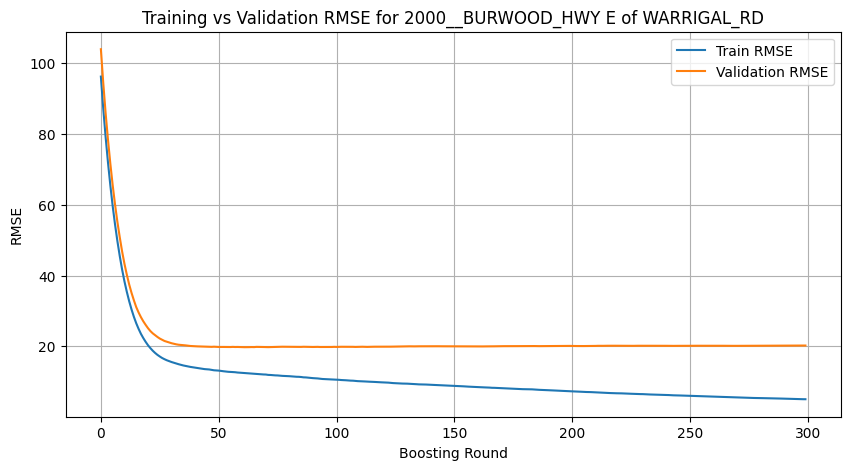

In [26]:

example_result = results_300[0]
training_curve = example_result["train_rmse_curve"]
validation_curve = example_result["val_rmse_curve"]

plt.figure(figsize=(10, 5))

plt.plot(training_curve, label="Train RMSE")
plt.plot(validation_curve, label="Validation RMSE")

plt.title(f"Training vs Validation RMSE for {example_result['site']}")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

---
## 7. Building XGBoost model for 100 estimators

In [24]:
models_100 = {}
results_100 = []

for col in wide_df.columns:
  series = wide_df[col].dropna()

  if len(series) < LOOKBACK + 20:
    continue

  X, y = create_features(series)

  train_end = int(len(X) * 0.70)
  val_end = int(len(X) * 0.85)

  x_train, y_train = X.iloc[:train_end], y.iloc[:train_end]

  x_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]

  x_test, y_test = X.iloc[val_end:], y.iloc[val_end:]


  model = XGBRegressor(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 5,
    subsample = 0.8,
    colsample_bytree=0.8,
    objective = "reg:squarederror",
    random_state = 42,
    )
  
  model.fit(
    x_train, 
    y_train,
    eval_set = [(x_train, y_train), (x_val, y_val)],
    verbose = False,
  )

  eval_results = model.evals_result()
  
  predictions = model.predict(x_test)

  # Calculate metrics

  mse = mean_squared_error(y_test, predictions)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_test, predictions)
  r2 = r2_score(y_test, predictions)

  models_100[col] = model

  results_100.append(
    {
      "site" : col,
      "mse" : mse,
      "rmse" : rmse,
      "mae" : mae,
      "r2" : r2,
      "train_rmse_curve" : eval_results["validation_0"]["rmse"],
      "val_rmse_curve" : eval_results["validation_1"]["rmse"],
    }
  )

  print(f"{col} | MSE: {mse:.2f} | RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.3f}")

2000__BURWOOD_HWY E of WARRIGAL_RD | MSE: 320.36 | RMSE: 17.90 | MAE: 13.33 | R²: 0.966
2000__TOORAK_RD W of WARRIGAL_RD | MSE: 331.06 | RMSE: 18.19 | MAE: 13.56 | R²: 0.961
2000__WARRIGAL_RD N of TOORAK_RD | MSE: 272.89 | RMSE: 16.52 | MAE: 11.57 | R²: 0.970
2000__WARRIGAL_RD S of BURWOOD_HWY | MSE: 490.95 | RMSE: 22.16 | MAE: 15.84 | R²: 0.969
2200__MAROONDAH_HWY E of UNION_RD | MSE: 177.97 | RMSE: 13.34 | MAE: 9.47 | R²: 0.952
2200__MAROONDAH_HWY W of UNION_RD | MSE: 203.38 | RMSE: 14.26 | MAE: 10.54 | R²: 0.947
2200__UNION_RD N of MAROONDAH_HWY | MSE: 119.09 | RMSE: 10.91 | MAE: 7.79 | R²: 0.963
2200__UNION_RD S of MAROONDAH_HWY | MSE: 123.25 | RMSE: 11.10 | MAE: 8.02 | R²: 0.965
2820__EARL_ST SE of PRINCESS_ST | MSE: 134.29 | RMSE: 11.59 | MAE: 8.47 | R²: 0.950
2820__PRINCESS_ST S of CHANDLER_HWY | MSE: 287.40 | RMSE: 16.95 | MAE: 12.08 | R²: 0.977
2825__BURKE_RD S of EASTERN_FWY | MSE: 275.11 | RMSE: 16.59 | MAE: 12.42 | R²: 0.971
2827__BULLEEN_RD N of THOMPSONS_RD | MSE: 321.41 

---
## 8. Training and validation curve for 100 estimators

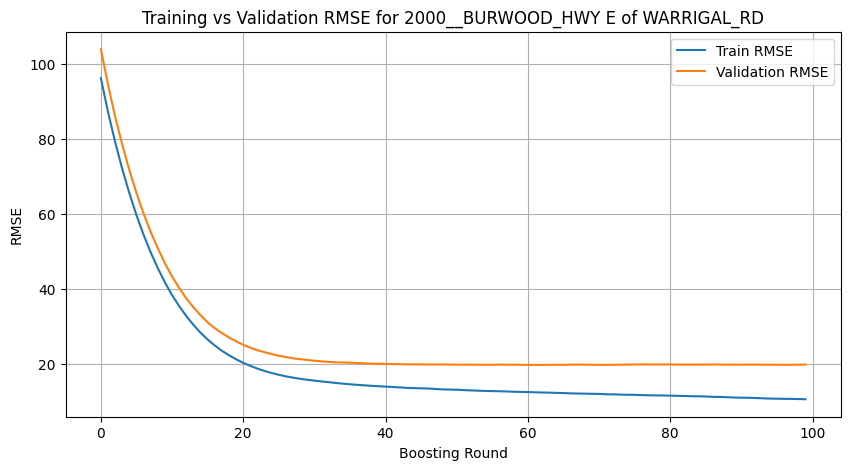

In [27]:
example_result = results_100[0]
training_curve = example_result["train_rmse_curve"]
validation_curve = example_result["val_rmse_curve"]

plt.figure(figsize=(10, 5))

plt.plot(training_curve, label="Train RMSE")
plt.plot(validation_curve, label="Validation RMSE")

plt.title(f"Training vs Validation RMSE for {example_result['site']}")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

---
## 9. Checking the metrics and results

In [29]:
results_df_100 = pd.DataFrame(results_100)

print("XGBoost Results (100 estimators):")
print("---------------------------------")

print( "number of trained models:", len(models_100))

print(f"\nAverage MSE: {results_df_100['mse'].mean():.2f}")
print(f"Average RMSE: {results_df_100['rmse'].mean():.2f}")
print(f"Average MAE: {results_df_100['mae'].mean():.2f}")
print(f"Average R²: {results_df_100['r2'].mean():.3f}")

print("\n First 5 results:")

display(results_df_100.head(6))

XGBoost Results (100 estimators):
---------------------------------
number of trained models: 139

Average MSE: 296.36
Average RMSE: 15.85
Average MAE: 11.52
Average R²: 0.937

 First 5 results:


,site,mse,rmse,mae,r2,train_rmse_curve,val_rmse_curve
0,2000__BURWOOD_HWY E of WARRIGAL_RD,320.358501,17.898561,13.326030,0.966459,"[96.22312455757366, 87.24729788261806, 79.2405...","[103.96053497977891, 94.50373988481766, 86.001..."
1,2000__TOORAK_RD W of WARRIGAL_RD,331.055004,18.194917,13.555374,0.960786,"[85.6219217874826, 77.64411080911565, 70.54206...","[91.4955968925185, 83.14573870307731, 75.62629..."
2,2000__WARRIGAL_RD N of TOORAK_RD,272.888725,16.519344,11.565908,0.969690,"[90.73533425571524, 82.21158777938575, 74.5588...","[96.15241276012378, 87.2886608327708, 79.46126..."
3,2000__WARRIGAL_RD S of BURWOOD_HWY,490.948831,22.157365,15.843836,0.969091,"[119.96864087024082, 108.66152778791405, 98.48...","[124.713361690468, 113.13188362718833, 102.626..."
4,2200__MAROONDAH_HWY E of UNION_RD,177.970930,13.340575,9.473540,0.951683,"[56.45633388816422, 51.24260820980035, 46.5653...","[61.07221137919182, 55.537135598180576, 50.645..."
5,2200__MAROONDAH_HWY W of UNION_RD,203.375827,14.260990,10.540209,0.947358,"[58.756145916110995, 53.37802493502052, 48.543...","[59.15889327415673, 53.677232386048836, 48.770..."


---
## 10. Saving the model and result file

In [30]:
joblib.dump(models_100, MODEL_FILE)

results_df_100.to_csv(RESULTS_FILE, index=False)

print("Saved XGBoost model to:")
print(MODEL_FILE)

print("\n Saved results to:")
print(RESULTS_FILE)

Saved XGBoost model to:
..\models\xgboost_model.pkl

 Saved results to:
..\models\xgboost_results.csv


---
## 11. Actual Vs Predicted traffic volume

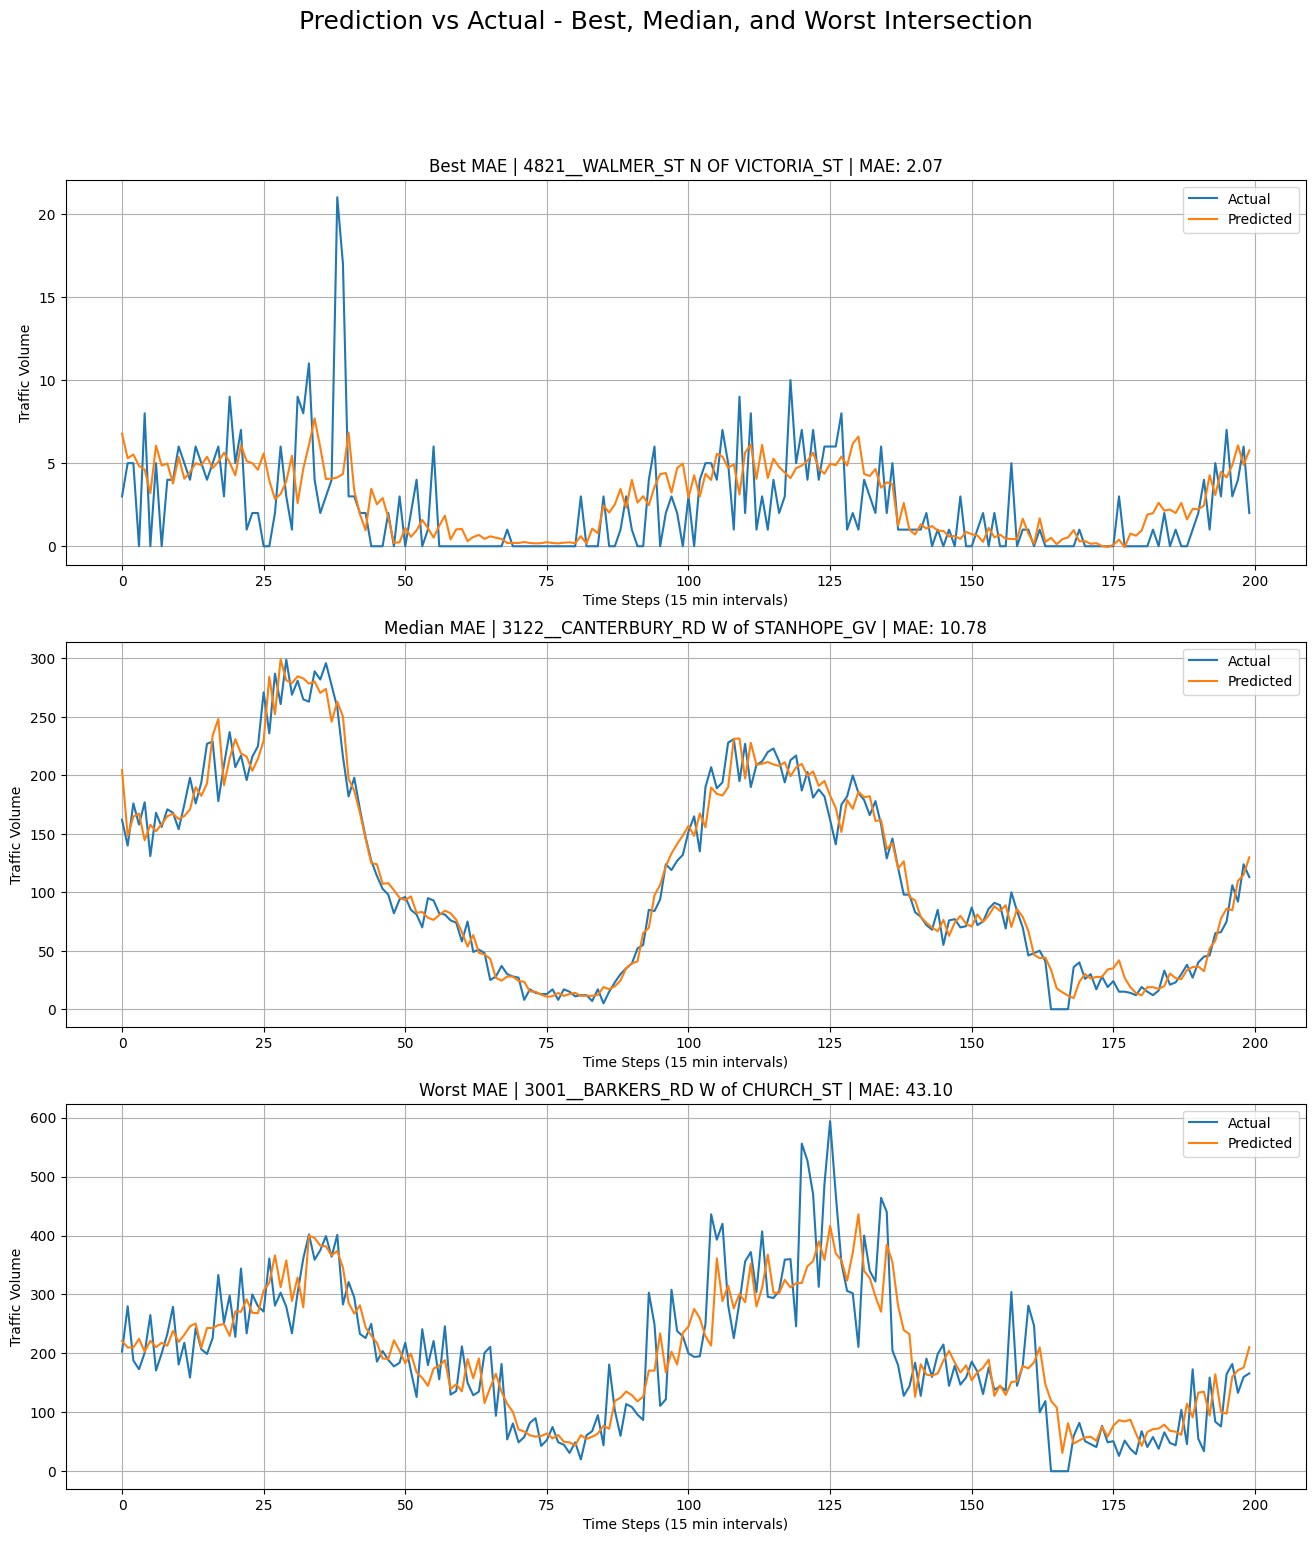

In [40]:
sorted_cols = results_df_100.sort_values("mae")
sample_cols = [
    sorted_cols.iloc[0]["site"],
    sorted_cols.iloc[len(sorted_cols) // 2]["site"],
    sorted_cols.iloc[-1]["site"],
]
labels = ["Best MAE", "Median MAE", "Worst MAE"]

fig, axes = plt.subplots(3, 1, figsize=(16, 17))

for ax, col, label in zip(axes, sample_cols, labels):

  series = wide_df[col].dropna()

  X, y = create_features(series)

  train_end = int(len(X) * 0.70)
  val_end = int(len(X) * 0.85)

  x_test = X.iloc[val_end:]
  y_test = y.iloc[val_end:]

  model = models_100[col]

  predictions = model.predict(x_test)

  ax.plot(
    y_test.values[:200],
    label="Actual",
  )
  ax.plot(
    predictions[:200],
    label="Predicted",
  )

  mae_values = sorted_cols[sorted_cols["site"] == col]["mae"].values[0]

  ax.set_title(f"{label} | {col} | MAE: {mae_values:.2f}")

  ax.set_xlabel("Time Steps (15 min intervals)")
  ax.set_ylabel("Traffic Volume")
  ax.legend()
  ax.grid(True)

plt.suptitle(
  "Prediction vs Actual - Best, Median, and Worst Intersection",
  fontsize=18,
)

plt.show()